In [ ]:
import numpy as np
import torch
from collections import defaultdict
from sklearn.model_selection import KFold
import os
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score, roc_curve, classification_report, confusion_matrix
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from collections import Counter
os.chdir("/mnt/sunxh/sunxh/wattmamba")  
print(os.getcwd())
from model.model import WaveCrossMamba,AnomalyDetectionModel
from utils.dataloader import SupervisedDataset,load_data_supervised
from train_test.anomaly_detection import test_model
import os
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.empty_cache()  


/mnt/sunxh/sunxh/wattmamba
测试过程。


In [3]:
import matplotlib.pyplot as plt
def plot_roc_pr_curves(fpr, tpr, roc_auc, precision, recall, pr_auc, title=""):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title(f'ROC Curve {title}')
    plt.legend(loc="lower right")
    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, color='red', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve {title}')
    plt.legend(loc="lower left")

    plt.tight_layout()
    plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, precision_recall_curve, auc, roc_curve
import numpy as np
import torch
from collections import defaultdict
from sklearn.model_selection import KFold
import os
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score, roc_curve, classification_report, confusion_matrix
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from collections import Counter
os.chdir("/mnt/sunxh/sunxh/wattmamba/")  
print(os.getcwd())
from model.model import WaveCrossMamba,AnomalyDetectionModel
from utils.dataloader import SupervisedDataset,load_data_supervised
from train_test.anomaly_detection import test_model
import os
import random
kmer_encode_dic={'A': 0, "C": 1, "G": 2, "T": 3}

def load_data_supervised(data_files, data_length, validation_split=0.0, pos_neg_ratio=0.5):
    X = []
    Y = []
    file_data_counts = {}
    total_data_count = 0
    positive_samples = []
    negative_samples = []  


    for file, label in data_files:
        with open(file) as f:
            count = 0
            for line in f:
                line = line.rstrip()
                items = line.split("\t")
                if line.startswith("read_id"):
                    continue
                signals = "|".join(items[9:14]).split("|")
                signal = np.array([float(signal) for signal in signals], dtype=np.float32)
                kmer = items[3]
                kmer = np.array([kmer_encode_dic[base] for base in kmer], dtype=np.int32)
                mean = np.array([float(item) for item in items[4].split("|")], dtype=np.float32)
                std = np.array([float(item) for item in items[5].split("|")], dtype=np.float32)
                intense = np.array([float(item) for item in items[6].split("|")], dtype=np.float32)
                dwell = np.array([float(item) for item in items[7].split("|")], dtype=np.float32) / 200.0
                base_quality = np.array([float(item) for item in items[8].split("|")], dtype=np.float32)
                base_quality = base_quality / 40.0

                x = [signal, kmer, mean, std, intense, dwell, base_quality]
                if label == 1:
                    positive_samples.append((x, label))
                else:
                    negative_samples.append((x, label))

                count += 1
                if count >= data_length:
                    break
            
            file_data_counts[file] = count
            total_data_count += count


    total_samples = min(len(positive_samples) + len(negative_samples), data_length * len(data_files))
    num_pos_samples = int(total_samples * pos_neg_ratio)
    num_neg_samples = total_samples - num_pos_samples


    positive_samples = random.sample(positive_samples, min(num_pos_samples, len(positive_samples)))
    negative_samples = random.sample(negative_samples, min(num_neg_samples, len(negative_samples)))


    combined = positive_samples + negative_samples
    random.shuffle(combined)


    X, Y = zip(*combined)

    for file, count in file_data_counts.items():
        print(f" {file}  {count} ")

    num_samples = len(X)
    val_size = int(num_samples * validation_split)

    X_train = X[val_size:]
    Y_train = Y[val_size:]
    X_val = X[:val_size]
    Y_val = Y[:val_size]

    return (X_train, Y_train), (X_val, Y_val)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def test_model(pretrain_model, model, test_loader, device):
    model.to(device)
    pretrain_model.to(device)
    all_labels = []
    all_preds = []
    all_probs = []

    model.eval()
    pretrain_model.eval()
    with torch.no_grad():
        for batch_idx, (data, rog, targets) in enumerate(test_loader):
            x, kmer, mean, std, intense, dwell, base_quality = data


            x = x.to(device)
            kmer = kmer.to(device)
            mean = mean.to(device)
            std = std.to(device)
            intense = intense.to(device)
            dwell = dwell.to(device)
            base_quality = base_quality.to(device)
            targets = targets.to(device)

            if targets.dtype != torch.long:
                targets = targets.long()
            x = x.unsqueeze(2)

            logits, ff = pretrain_model(x, kmer, mean, std, intense, dwell, base_quality)
            y_pred = model(logits).to(device)
            
            probs = torch.softmax(y_pred, dim=1).cpu().numpy()[:, 1]

            all_labels.extend(targets.cpu().numpy())
            all_preds.extend(np.argmax(y_pred.cpu().numpy(), axis=1))
            all_probs.extend(probs)
    

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)


    cm = confusion_matrix(all_labels, all_preds)
    tn, fp, fn, tp = cm.ravel()


    roc_auc = roc_auc_score(all_labels, all_probs)
    precision, recall, _ = precision_recall_curve(all_labels, all_probs)
    pr_auc = auc(recall, precision)
    fpr_all, tpr_all, _ = roc_curve(all_labels, all_probs)


    min_len_roc = min(len(fpr_all), len(tpr_all))
    fpr_all, tpr_all = fpr_all[:min_len_roc], tpr_all[:min_len_roc]

    min_len_pr = min(len(precision), len(recall))
    precision, recall = precision[:min_len_pr], recall[:min_len_pr]


    f1_score = (2 * tp / (2 * tp + fp + fn)) if (2 * tp + fp + fn) > 0 else 0
    precision_score = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_score = tp / (tp + fn) if (tp + fn) > 0 else 0
    tpr_value = tp / (tp + fn) if (tp + fn) > 0 else 0
    fnr_value = fn / (tp + fn) if (tp + fn) > 0 else 0
    print(roc_auc,pr_auc)
    return fpr_all, tpr_all, precision, recall, roc_auc, pr_auc, tn, fp, fn, tp,f1_score,precision_score,recall_score,tpr_value,fnr_value,all_labels,all_preds,all_probs
data_files = [
    ('/mnt/sunxh/sunxh/benchmark/rna002-ivt/m7g.test.tsv', 1),
    ('/mnt/sunxh/sunxh/benchmark/rna002-ivt/IVT_normalG.test.tsv', 0)
]
data_length = int(65)
(X_test, Y_test),_ = load_data_supervised(data_files, data_length, validation_split=0.0)
test_dataset = SupervisedDataset(X_test, Y_test,augment=False, num_aug=1)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=2000,
    shuffle=False,
    num_workers=16,
    pin_memory=True
)
import pandas as pd
pretrained_feature_extractor  = WaveCrossMamba(device=device,d_model=128).to(device)
fine_tune_model  = AnomalyDetectionModel(feature_dim=128, num_classes=2).to(device)
pretrained_feature_extractor.load_state_dict(torch.load(f'/mnt/sunxh/sunxh/wattmamba/save_result/other_base/backdone_m7G.pth',map_location=device))
fine_tune_model.load_state_dict(torch.load(f'/mnt/sunxh/sunxh/wattmamba/save_result/other_base/classierm7G.pth', map_location=device))
print("processing...")
fpr_all, tpr_all, precision_all, recall_all, roc_auc_all, pr_auc_all, tn, fp, fn, tp,f1_score,precision_score,recall_score,tpr_value,fnr_value,all_labels,all_preds,all_probs = test_model(pretrained_feature_extractor, fine_tune_model, test_loader, device)
df_roc = pd.DataFrame({"FPR": fpr_all, "TPR": tpr_all, "AUC": [roc_auc_all] * len(fpr_all)})
df_pr = pd.DataFrame({"Precision": precision_all, "Recall": recall_all, "AUC": [pr_auc_all] * len(precision_all)})
df_roc.to_csv('/mnt/sunxh/sunxh/wattmamba/new_result/fig5_m7G_roc.csv', index=False)
df_pr.to_csv('/mnt/sunxh/sunxh/wattmamba/new_result/fig5_m7G_pr.csv', index=False)

In [ ]:
data_files = [
    ('/mnt/sunxh/Datasets_RNA/curlcake_RNA004/train_and_test/m6A_test.tsv', 1),
    ('/mnt/sunxh/Datasets_RNA/curlcake_RNA004/train_and_test/normala_test.tsv', 0)
]
data_length = int(4000)
(X_test, Y_test),_ = load_data_supervised(data_files, data_length, validation_split=0.0)
test_dataset = SupervisedDataset(X_test, Y_test,augment=False, num_aug=1)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=2000,
    shuffle=False,
    num_workers=16,
    pin_memory=True
)
pretrained_feature_extractor  = WaveCrossMamba(device=device,d_model=128).to(device)
fine_tune_model  = AnomalyDetectionModel(feature_dim=128, num_classes=2).to(device)
pretrained_feature_extractor.load_state_dict(torch.load(f'/mnt/sunxh/sunxh/wattmamba/save_result/RNA004_NEW/m6a_curlcake512_backdone.pth',map_location=device))
fine_tune_model.load_state_dict(torch.load(f'/mnt/sunxh/sunxh/wattmamba/save_result/RNA004_NEW/m6a_curlcake512_classifier.pth', map_location=device))
print("processing...")
fpr_all, tpr_all, precision_all, recall_all, roc_auc_all, pr_auc_all, tn, fp, fn, tp,f1_score,precision_score,recall_score,tpr_value,fnr_value,all_labels,all_preds,all_probs = test_model(pretrained_feature_extractor, fine_tune_model, test_loader, device)

文件 /mnt/sunxh/Datasets_RNA/curlcake_RNA004/train_and_test/m6A_test.tsv 中加载了 4000 条数据
文件 /mnt/sunxh/Datasets_RNA/curlcake_RNA004/train_and_test/normala_test.tsv 中加载了 4000 条数据
总数据量: 8000
训练集大小: 8000
验证集大小: 0
正样本数: 4000, 负样本数: 4000, 目标比例: 0.50
开始评估二分类异常检测模型...
0.9548015525228496
0.9906591875 0.9897975518390498


In [ ]:
data_files = [
    ('/mnt/sunxh/Datasets_RNA/curlcake_RNA004/train_and_test/y_test.tsv', 1),
    ('/mnt/sunxh/Datasets_RNA/curlcake_RNA004/train_and_test/normalt_test.tsv', 0)
]
data_length = int(500)
(X_test, Y_test),_ = load_data_supervised(data_files, data_length, validation_split=0.0)
test_dataset = SupervisedDataset(X_test, Y_test,augment=False, num_aug=1)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=2000,
    shuffle=False,
    num_workers=16,
    pin_memory=True
)
pretrained_feature_extractor  = WaveCrossMamba(device=device,d_model=128).to(device)
fine_tune_model  = AnomalyDetectionModel(feature_dim=128, num_classes=2).to(device)
pretrained_feature_extractor.load_state_dict(torch.load(f'/mnt/sunxh/sunxh/wattmamba/save_result/RNA004/Backdone_RNA004_y.pth',map_location=device))
fine_tune_model.load_state_dict(torch.load(f'/mnt/sunxh/sunxh/wattmamba/save_result/RNA004/Classifier_RNA004_y.pth', map_location=device))
fpr_all, tpr_all, precision_all, recall_all, roc_auc_all, pr_auc_all, tn, fp, fn, tp,f1_score,precision_score,recall_score,tpr_value,fnr_value,all_labels,all_preds,all_probs = test_model(pretrained_feature_extractor, fine_tune_model, test_loader, device)

文件 /mnt/sunxh/Datasets_RNA/curlcake_RNA004/train_and_test/y_test.tsv 中加载了 500 条数据
文件 /mnt/sunxh/Datasets_RNA/curlcake_RNA004/train_and_test/normalt_test.tsv 中加载了 500 条数据
总数据量: 1000
训练集大小: 1000
验证集大小: 0
正样本数: 500, 负样本数: 500, 目标比例: 0.50
开始评估二分类异常检测模型...
0.916015625
0.967584 0.9562574410967452


In [ ]:
data_files = [
    ('/mnt/sunxh/Datasets_RNA/curlcake_RNA004/train_and_test/m1y_test.tsv', 1),
    ('/mnt/sunxh/Datasets_RNA/curlcake_RNA004/train_and_test/normalt_test.tsv', 0)
]
data_length = int(4000)
(X_test, Y_test),_ = load_data_supervised(data_files, data_length, validation_split=0.0)
test_dataset = SupervisedDataset(X_test, Y_test,augment=False, num_aug=1)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=2000,
    shuffle=False,
    num_workers=16,
    pin_memory=True
)
pretrained_feature_extractor  = WaveCrossMamba(device=device,d_model=128).to(device)
fine_tune_model  = AnomalyDetectionModel(feature_dim=128, num_classes=2).to(device)
pretrained_feature_extractor.load_state_dict(torch.load(f'/mnt/sunxh/sunxh/wattmamba/save_result/RNA004_NEW/m1y_curlcake512_backdone.pth',map_location=device))
fine_tune_model.load_state_dict(torch.load(f'/mnt/sunxh/sunxh/wattmamba/save_result/RNA004_NEW/m1y_curlcake512_classifier.pth', map_location=device))
fpr_all, tpr_all, precision_all, recall_all, roc_auc_all, pr_auc_all, tn, fp, fn, tp,f1_score,precision_score,recall_score,tpr_value,fnr_value,all_labels,all_preds,all_probs = test_model(pretrained_feature_extractor, fine_tune_model, test_loader, device)

文件 /mnt/sunxh/Datasets_RNA/curlcake_RNA004/train_and_test/m1y_test.tsv 中加载了 4000 条数据
文件 /mnt/sunxh/Datasets_RNA/curlcake_RNA004/train_and_test/normalt_test.tsv 中加载了 4000 条数据
总数据量: 8000
训练集大小: 8000
验证集大小: 0
正样本数: 4000, 负样本数: 4000, 目标比例: 0.50
开始评估二分类异常检测模型...
0.9433424089200052
0.9697779999999998 0.9783546628907459


In [ ]:
data_files = [
    ('/mnt/sunxh/Datasets_RNA/curlcake_RNA004/train_and_test/m1y_test.tsv', 1),
    ('/mnt/sunxh/Datasets_RNA/curlcake_RNA004/train_and_test/normalt_test.tsv', 0)
]
data_length = int(500)
(X_test, Y_test),_ = load_data_supervised(data_files, data_length, validation_split=0.0)
test_dataset = SupervisedDataset(X_test, Y_test,augment=False, num_aug=1)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=2000,
    shuffle=False,
    num_workers=16,
    pin_memory=True
)
pretrained_feature_extractor  = WaveCrossMamba(device=device,d_model=128).to(device)
fine_tune_model  = AnomalyDetectionModel(feature_dim=128, num_classes=2).to(device)
pretrained_feature_extractor.load_state_dict(torch.load(f'/mnt/sunxh/sunxh/wattmamba/save_result/RNA004_NEW/m1y_curlcake512_backdone.pth',map_location=device))
fine_tune_model.load_state_dict(torch.load(f'/mnt/sunxh/sunxh/wattmamba/save_result/RNA004_NEW/m1y_curlcake512_classifier.pth', map_location=device))
fpr_all, tpr_all, precision_all, recall_all, roc_auc_all, pr_auc_all, tn, fp, fn, tp,f1_score,precision_score,recall_score,tpr_value,fnr_value,all_labels,all_preds,all_probs = test_model(pretrained_feature_extractor, fine_tune_model, test_loader, device)

找到 PR 文件：
   RNA004_Y_pr.csv
   RNA004_ac4C_pr.csv
   RNA004_hm5C_pr.csv
   RNA004_m1Y_pr.csv
   RNA004_m5C_pr.csv
   RNA004_m5u_pr.csv
   RNA004_m6A_pr.csv
AUPR 数值表已保存: /mnt/sunxh/sunxh/wattmamba/new_result/RNA004_mods_AUPR_summary.csv


/tmp/ipykernel_92581/966814538.py:74: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


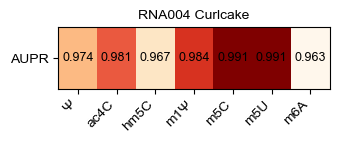

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"  

base_dir = "/mnt/sunxh/sunxh/wattmamba/new_result"

pr_files = sorted(glob.glob(os.path.join(base_dir, "RNA004_*_pr.csv")))
for f in pr_files:
    print("  ", os.path.basename(f))

rows = []
for f in pr_files:
    df = pd.read_csv(f)

    col_map = {c.lower(): c for c in df.columns}
    pcol = col_map.get("precision", col_map.get("prec"))
    rcol = col_map.get("recall", col_map.get("rec"))

    if pcol is None or rcol is None:
        raise ValueError(f"{f}  precision/recall ")

    recall = df[rcol].to_numpy(dtype=float)
    precision = df[pcol].to_numpy(dtype=float)

    order = np.argsort(recall)
    recall = recall[order]
    precision = precision[order]

    aupr = np.trapz(precision, recall)

    mod = os.path.basename(f).replace("RNA004_", "").replace("_pr.csv", "")
    rows.append({"mod": mod, "AUPR": aupr})

df_aupr = pd.DataFrame(rows).sort_values("mod")

out_csv = os.path.join(base_dir, "RNA004_mods_AUPR_summary.csv")
df_aupr.to_csv(out_csv, index=False)
print("AUPR :", out_csv)

data = df_aupr["AUPR"].to_numpy(dtype=float)[np.newaxis, :] 

fig, ax = plt.subplots(figsize=(0.5 * len(df_aupr), 0.8)) 

im = ax.imshow(data, aspect="auto", origin="lower", cmap="OrRd")

ax.set_xticks(np.arange(len(df_aupr)))

label_map = {
    "Y": "Ψ", 
    "m1Y": "m1Ψ",
    "m5u": "m5U", 
}
xticklabels = [label_map.get(m, m) for m in df_aupr["mod"]]

ax.set_xticklabels(xticklabels, rotation=45, ha="right")
ax.set_yticks([0])
ax.set_yticklabels(["AUPR"])

for j in range(data.shape[1]):
    val = data[0, j]
    ax.text(
        j, 0, f"{val:.3f}",
        ha="center", va="center",
        color="black" if val > 0.5 else "black",
        fontsize=9,
    )
plt.title("RNA004 Curlcake",fontsize=10)
plt.tight_layout()
out_pdf = os.path.join(base_dir, "RNA004_mods_AUPR_heatmap.pdf")
plt.savefig(out_pdf, dpi=1200,bbox_inches="tight")
plt.show()
